In [2]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import plotly_express as px
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import LinearSVC

In [3]:
df=pd.read_csv('gene_expression.csv')
df

,Gene One,Gene Two,Cancer Present
0,4.3,3.9,1
1,2.5,6.3,0
2,5.7,3.9,1
3,6.1,6.2,0
4,7.4,3.4,1
...,...,...,...
2995,5.0,6.5,1
2996,3.4,6.6,0
2997,2.7,6.5,0
2998,3.3,5.6,0


In [4]:
df.shape

(3000, 3)

In [5]:
df.isnull().sum()

Gene One          0
Gene Two          0
Cancer Present    0
dtype: int64

<Axes: >

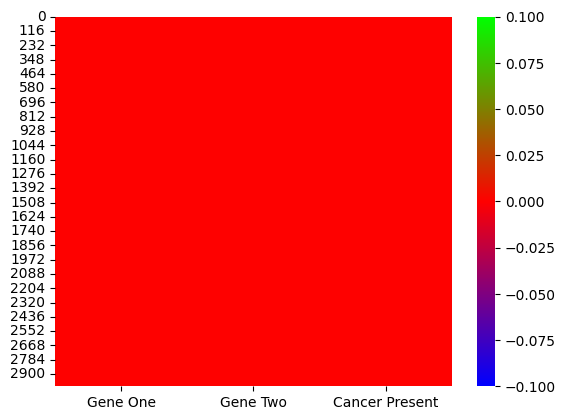

In [6]:
sns.heatmap(df.isnull(),cmap='brg')

In [ ]:
fig = px.bar(df.groupby('Gene One')['Cancer Present'].sum().reset_index(),
             x='Gene One', y='Cancer Present')
fig.show()

In [9]:
x=df.drop(columns=['Cancer Present'])
y=df['Cancer Present']

In [10]:
scale=StandardScaler()

array([[-0.71120047, -0.87371191],
       [-1.6958386 ,  0.51454023],
       [ 0.05462918, -0.87371191],
       ...,
       [-1.58643436,  0.63022791],
       [-1.25822165,  0.10963336],
       [-0.54709412,  1.61357318]])

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=46,test_size=0.25)

In [28]:
x_scale=scale.fit_transform(x_train)
x_scale_test=scale.fit_transform(x_test)

In [25]:
model=SVC()
model

SVC()

In [29]:
y_pred=model.fit(x_scale,y_train).predict(x_scale_test)

In [30]:
y_pred

array([0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,

In [32]:
acc=accuracy_score(y_test,y_pred)
acc

0.9333333333333333

In [35]:
clt=classification_report(y_test,y_pred)
print(clt)

              precision    recall  f1-score   support

           0       0.94      0.93      0.93       377
           1       0.93      0.94      0.93       373

    accuracy                           0.93       750
   macro avg       0.93      0.93      0.93       750
weighted avg       0.93      0.93      0.93       750

